# Single Backtest Viewer

Auto-discovers the latest single backtest run from either:
- `eval_results/backtest/<run_dir>`
- `eval_results/backtest/ab_pairs/<pair_dir>/run_a|run_b`

Focus:
- single-run summary statistics
- equity curve vs benchmark
- portfolio weights and concentration
- order flow and trading cost totals


In [ ]:
from pathlib import Path
import json
import re
import sys
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

def _resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for c in (cwd, cwd.parent):
        if (c / 'research/configs/backtest_current_baseline.json').exists():
            return c
    return cwd

REPO_ROOT = _resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from tools.monthly_commentary_context import resolve_latest_default_baseline_run

def _resolve_backtest_root() -> Path:
    for c in (REPO_ROOT / 'eval_results/backtest', Path('eval_results/backtest'), Path('../eval_results/backtest')):
        if c.exists():
            return c
    return REPO_ROOT / 'eval_results/backtest'

def _resolve_baseline_config_path() -> Path:
    for c in (
        REPO_ROOT / 'research/configs/backtest_current_baseline.json',
        Path('research/configs/backtest_current_baseline.json'),
        Path('../research/configs/backtest_current_baseline.json'),
    ):
        if c.exists():
            return c
    return REPO_ROOT / 'research/configs/backtest_current_baseline.json'

def _is_run_dir(path: Path) -> bool:
    return path.is_dir() and (path / 'summary.json').exists() and (path / 'equity_curve.csv').exists()

def _has_daily_market_value(run_dir: Path) -> bool:
    return (run_dir / 'daily_market_value.csv').exists()

def _completed_at(run_dir: Path):
    candidates = [
        run_dir / 'summary.json',
        run_dir / 'equity_curve.csv',
        run_dir / 'daily_market_value.csv',
        run_dir / 'weights_history.csv',
        run_dir / 'orders_history.csv',
        run_dir / 'rebalance_log.jsonl',
    ]
    mtimes = [p.stat().st_mtime for p in candidates if p.exists()]
    return pd.to_datetime(max(mtimes), unit='s') if mtimes else pd.Timestamp.min

def _latest_trade_date(run_dir: Path):
    try:
        eq = pd.read_csv(run_dir / 'equity_curve.csv', usecols=['trade_date'])
        return pd.to_datetime(eq['trade_date']).max()
    except Exception:
        return pd.NaT

def _collect_runs(root: Path) -> list[dict]:
    runs = []
    if root.exists():
        for p in root.iterdir():
            if p.name == 'ab_pairs':
                continue
            if _is_run_dir(p):
                runs.append({'run_dir': p, 'source': 'single', 'pair': None})

    pair_root = root / 'ab_pairs'
    if pair_root.exists():
        for pair in pair_root.iterdir():
            if not pair.is_dir():
                continue
            for child in ('run_a', 'run_b'):
                rp = pair / child
                if _is_run_dir(rp):
                    runs.append({'run_dir': rp, 'source': f'ab_{child}', 'pair': pair.name})

    for r in runs:
        s = r['run_dir'] / 'summary.json'
        e = r['run_dir'] / 'equity_curve.csv'
        summary = json.loads(s.read_text())
        r['completed_at'] = _completed_at(r['run_dir'])
        r['summary_end_date'] = pd.to_datetime(summary.get('end_date'), errors='coerce')
        r['latest_trade_date'] = _latest_trade_date(r['run_dir'])
        r['has_daily_market_value'] = _has_daily_market_value(r['run_dir'])

    runs.sort(
        key=lambda x: (
            x['completed_at'],
            x['latest_trade_date'] if pd.notna(x['latest_trade_date']) else pd.Timestamp.min,
            x['summary_end_date'] if pd.notna(x['summary_end_date']) else pd.Timestamp.min,
            x['has_daily_market_value'],
        ),
        reverse=True,
    )
    return runs

BACKTEST_ROOT = _resolve_backtest_root()
BASELINE_CONFIG_PATH = _resolve_baseline_config_path()
RUNS = _collect_runs(BACKTEST_ROOT)
assert RUNS, f'No valid backtest runs found under {BACKTEST_ROOT.resolve()}'
try:
    DEFAULT_RUN_DIR = resolve_latest_default_baseline_run(
        backtest_root=BACKTEST_ROOT,
        baseline_config_path=BASELINE_CONFIG_PATH,
    )
except Exception:
    DEFAULT_RUN_DIR = Path(RUNS[0]['run_dir'])

top = pd.DataFrame([
    {
        'rank': i + 1,
        'run_dir': str(r['run_dir']),
        'source': r['source'],
        'pair': r['pair'],
        'has_daily_market_value': r['has_daily_market_value'],
        'summary_end_date': r['summary_end_date'],
        'latest_trade_date': r['latest_trade_date'],
        'completed_at': r['completed_at'],
    }
    for i, r in enumerate(RUNS[:12])
])
display(top)


In [ ]:
# Defaults to the latest completed run in the canonical current_baseline family.
RUN_DIR = Path(DEFAULT_RUN_DIR)
# RUN_DIR = Path('eval_results/backtest/ab_pairs/<pair_dir>/run_b')

summary = json.loads((RUN_DIR / 'summary.json').read_text())
eq = pd.read_csv(RUN_DIR / 'equity_curve.csv')
eq['trade_date'] = pd.to_datetime(eq['trade_date'])
daily_path = RUN_DIR / 'daily_market_value.csv'
daily_eq = pd.read_csv(daily_path) if daily_path.exists() else None
if daily_eq is not None and 'trade_date' in daily_eq.columns:
    daily_eq['trade_date'] = pd.to_datetime(daily_eq['trade_date'])
weights_path = RUN_DIR / 'weights_history.csv'
orders_path = RUN_DIR / 'orders_history.csv'
weights_history = pd.read_csv(weights_path) if weights_path.exists() else None
orders_history = pd.read_csv(orders_path) if orders_path.exists() else None
if weights_history is not None and 'trade_date' in weights_history.columns:
    weights_history['trade_date'] = pd.to_datetime(weights_history['trade_date'])
if orders_history is not None and 'trade_date' in orders_history.columns:
    orders_history['trade_date'] = pd.to_datetime(orders_history['trade_date'])

print('Selected run:', RUN_DIR)
print('Date window:', summary.get('start_date'), '->', summary.get('end_date'))
print('Latest trade date:', eq['trade_date'].max())
print('Has daily_market_value:', daily_eq is not None)
print('Has weights_history:', weights_history is not None)
print('Has orders_history:', orders_history is not None)


In [3]:
summary_keys = [
    'total_return', 'cagr', 'annualized_volatility', 'sharpe', 'max_drawdown',
    'tracking_error', 'realized_active_information_ratio',
    'average_ic', 'average_breadth_proxy', 'average_transfer_coefficient',
    'average_transfer_coefficient_corrected', 'average_transfer_coefficient_legacy_proxy',
    'implied_information_ratio',
    'average_raw_turnover', 'average_executed_turnover', 'average_turnover_constraint_drag',
    'rebalance_points', 'final_nav', 'initial_capital'
]
summary_view = pd.DataFrame([
    {'metric': k, 'value': summary.get(k)} for k in summary_keys if k in summary
])
if {'average_transfer_coefficient_corrected', 'average_transfer_coefficient_legacy_proxy'} <= set(summary_view['metric']):
    corrected = float(summary.get('average_transfer_coefficient_corrected'))
    legacy = float(summary.get('average_transfer_coefficient_legacy_proxy'))
    summary_view = pd.concat([
        summary_view,
        pd.DataFrame([
            {'metric': 'transfer_coefficient_gap_legacy_minus_corrected', 'value': legacy - corrected},
            {'metric': 'transfer_coefficient_ratio_corrected_vs_legacy', 'value': corrected / legacy if legacy else float('nan')},
        ])
    ], ignore_index=True)
summary_view


,metric,value
0,total_return,2.294357e-02
1,cagr,5.687192e-03
2,annualized_volatility,2.528809e-01
3,sharpe,1.515790e-01
4,max_drawdown,-3.989511e-01
5,tracking_error,6.128474e-02
6,realized_active_information_ratio,-7.003704e-01
7,average_ic,3.702979e-04
8,average_breadth_proxy,9.251710e+01
9,average_transfer_coefficient,2.857231e-01


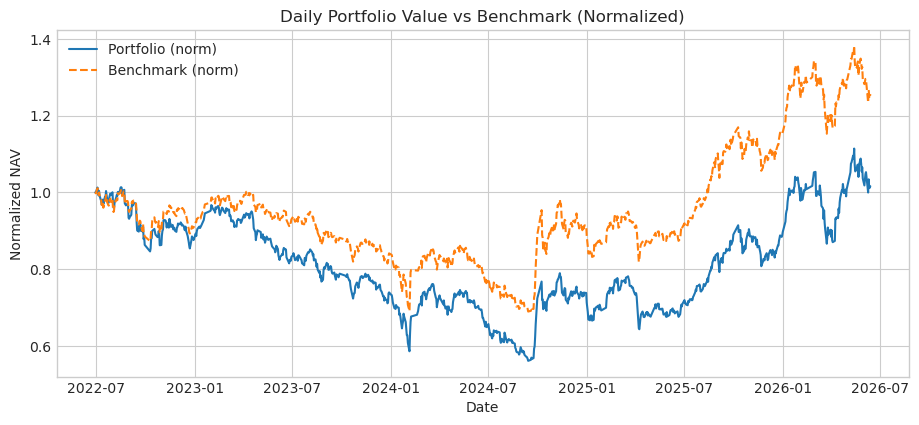

In [4]:
eq_plot = daily_eq.copy() if daily_eq is not None else eq.copy()
if daily_eq is not None:
    eq_plot['portfolio_nav_norm'] = eq_plot['portfolio_value'] / float(eq_plot['portfolio_value'].iloc[0])
    eq_plot['benchmark_nav_norm'] = eq_plot['benchmark_value'] / float(eq_plot['benchmark_value'].iloc[0])
    plot_title = 'Daily Portfolio Value vs Benchmark (Normalized)'
else:
    eq_plot['portfolio_nav_norm'] = eq_plot['nav'] / float(eq_plot['nav'].iloc[0])
    eq_plot['benchmark_nav_norm'] = (1.0 + pd.to_numeric(eq_plot['benchmark_return'], errors='coerce').fillna(0.0)).cumprod()
    plot_title = 'Equity Curve vs Benchmark (Normalized)'

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(eq_plot['trade_date'], eq_plot['portfolio_nav_norm'], label='Portfolio (norm)')
ax.plot(eq_plot['trade_date'], eq_plot['benchmark_nav_norm'], label='Benchmark (norm)', linestyle='--')
ax.set_title(plot_title)
ax.set_xlabel('Date')
ax.set_ylabel('Normalized NAV')
ax.legend()
plt.show()


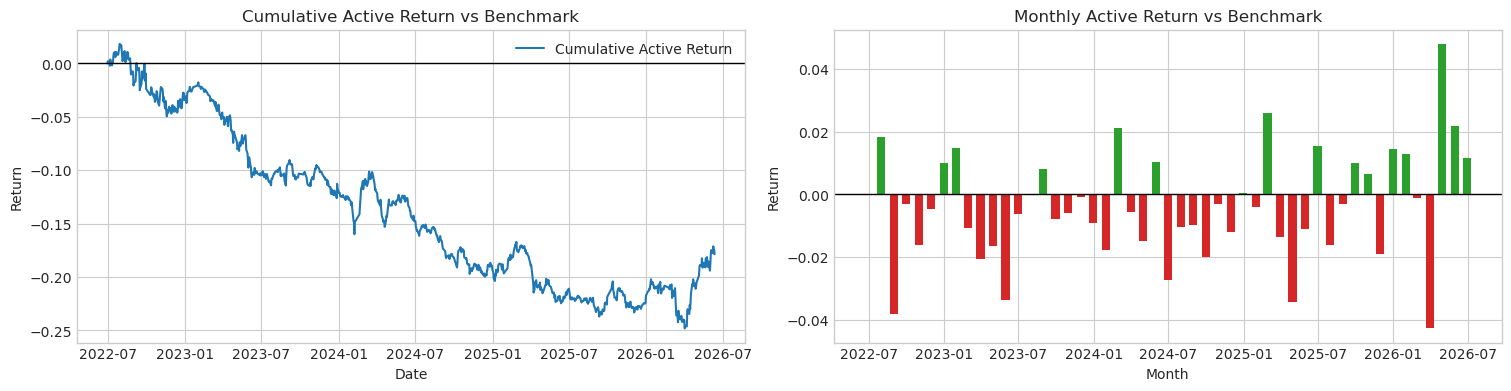

In [5]:
eq_plot = daily_eq.copy() if daily_eq is not None else eq.copy()
eq_plot['active_return'] = pd.to_numeric(eq_plot['portfolio_return'], errors='coerce').fillna(0.0) - pd.to_numeric(eq_plot['benchmark_return'], errors='coerce').fillna(0.0)
eq_plot['cum_active_return'] = (1.0 + eq_plot['active_return']).cumprod() - 1.0
monthly_active = (
    eq_plot.set_index('trade_date')['active_return']
    .resample('ME')
    .apply(lambda s: (1.0 + s).prod() - 1.0)
    .rename('monthly_active_return')
    .reset_index()
)
monthly_active['bar_color'] = monthly_active['monthly_active_return'].apply(lambda v: '#2ca02c' if v >= 0 else '#d62728')

fig, axes = plt.subplots(1, 2, figsize=(15, 3.8), constrained_layout=True)

axes[0].plot(eq_plot['trade_date'], eq_plot['cum_active_return'], label='Cumulative Active Return')
axes[0].axhline(0.0, color='black', linewidth=1)
axes[0].set_title('Cumulative Active Return vs Benchmark')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Return')
axes[0].legend()

axes[1].bar(
    monthly_active['trade_date'],
    monthly_active['monthly_active_return'],
    width=20,
    color=monthly_active['bar_color'],
)
axes[1].axhline(0.0, color='black', linewidth=1)
axes[1].set_title('Monthly Active Return vs Benchmark')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Return')

plt.show()


In [6]:
cost_series = pd.to_numeric(eq['cost'], errors='coerce').fillna(0.0) if 'cost' in eq.columns else pd.Series(0.0, index=eq.index)
turnover_series = pd.to_numeric(eq['turnover'], errors='coerce').fillna(0.0) if 'turnover' in eq.columns else pd.Series(0.0, index=eq.index)
raw_turnover_series = pd.to_numeric(eq['raw_turnover'], errors='coerce').fillna(0.0) if 'raw_turnover' in eq.columns else pd.Series(0.0, index=eq.index)

execution_summary = pd.DataFrame([
    {'metric': 'rebalance_rows', 'value': int(len(eq))},
    {'metric': 'total_cost', 'value': float(cost_series.sum())},
    {'metric': 'avg_cost_per_rebalance', 'value': float(cost_series.mean()) if len(cost_series) else 0.0},
    {'metric': 'total_executed_turnover', 'value': float(turnover_series.sum())},
    {'metric': 'total_raw_turnover', 'value': float(raw_turnover_series.sum())},
])
display(execution_summary)

if orders_history is not None and len(orders_history) > 0:
    est_cost_col = pd.to_numeric(orders_history.get('estimated_cost', 0.0), errors='coerce').fillna(0.0)
    notional_col = pd.to_numeric(orders_history.get('notional', 0.0), errors='coerce').fillna(0.0)
    buys = int((orders_history.get('action', '') == 'BUY').sum()) if 'action' in orders_history.columns else 0
    sells = int((orders_history.get('action', '') == 'SELL').sum()) if 'action' in orders_history.columns else 0
    order_summary = pd.DataFrame([
        {'metric': 'orders_count', 'value': int(len(orders_history))},
        {'metric': 'buy_orders', 'value': buys},
        {'metric': 'sell_orders', 'value': sells},
        {'metric': 'gross_notional_traded', 'value': float(notional_col.abs().sum())},
        {'metric': 'net_notional_traded', 'value': float(notional_col.sum())},
        {'metric': 'orders_estimated_cost_total', 'value': float(est_cost_col.sum())},
    ])
    display(order_summary)
else:
    print('orders_history.csv not found for selected run.')


,metric,value
0,rebalance_rows,49.000000
1,total_cost,10824.661674
2,avg_cost_per_rebalance,220.911463
3,total_executed_turnover,26.305061
4,total_raw_turnover,81.215837


,metric,value
0,orders_count,1.287000e+04
1,buy_orders,4.203000e+03
2,sell_orders,8.667000e+03
3,gross_notional_traded,2.164932e+07
4,net_notional_traded,-8.092464e-01
5,orders_estimated_cost_total,1.082466e+04


,metric,value
0,latest_trade_date,2026-06-12 00:00:00
1,previous_trade_date,2026-05-29 00:00:00
2,positions_count,250
3,sum_weights,1.0
4,top_10_weight,0.233019
5,top_20_weight,0.392893
6,hhi,0.012301
7,effective_n,81.293673


,trade_date,symbol,weight
0,2026-06-12,SZ300136,0.034501
1,2026-06-12,SZ002008,0.029484
2,2026-06-12,SZ002281,0.026672
3,2026-06-12,SZ002432,0.024193
4,2026-06-12,SZ002353,0.021491
5,2026-06-12,SH600487,0.020706
6,2026-06-12,SZ002273,0.019486
7,2026-06-12,SZ001389,0.019356
8,2026-06-12,SH688525,0.018790
9,2026-06-12,SZ300432,0.018339


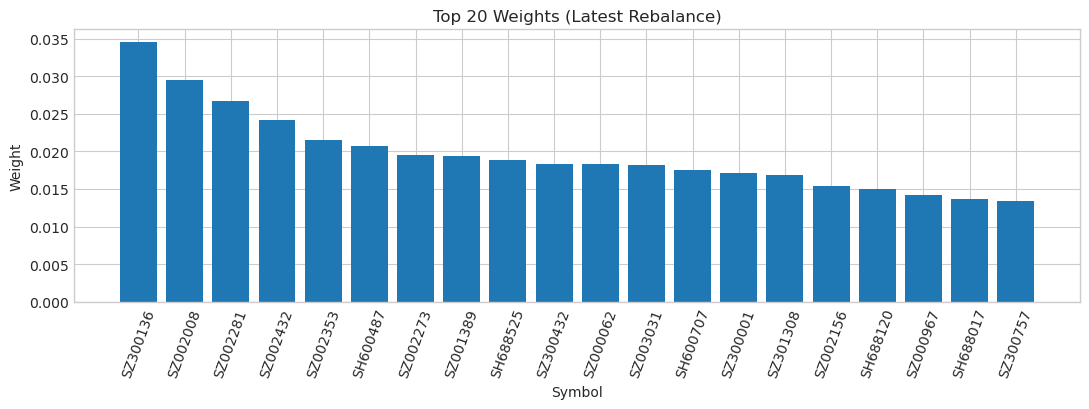

,symbol,latest_weight,prev_weight,delta_weight,abs_delta_weight
0,SZ301308,0.016798,2.218150e-04,0.016576,0.016576
1,SZ002156,0.015422,5.462476e-04,0.014876,0.014876
2,SZ300757,0.013461,1.784422e-04,0.013283,0.013283
3,SZ002281,0.026672,1.446409e-02,0.012208,0.012208
4,SH688234,0.011522,2.846444e-06,0.011519,0.011519
5,SZ300679,0.011198,3.314279e-08,0.011198,0.011198
6,SZ000539,0.011053,3.274836e-08,0.011053,0.011053
7,SH600378,0.010676,3.178918e-08,0.010676,0.010676
8,SH688220,0.013053,2.955728e-03,0.010098,0.010098
9,SH600487,0.020706,3.072980e-02,-0.010023,0.010023


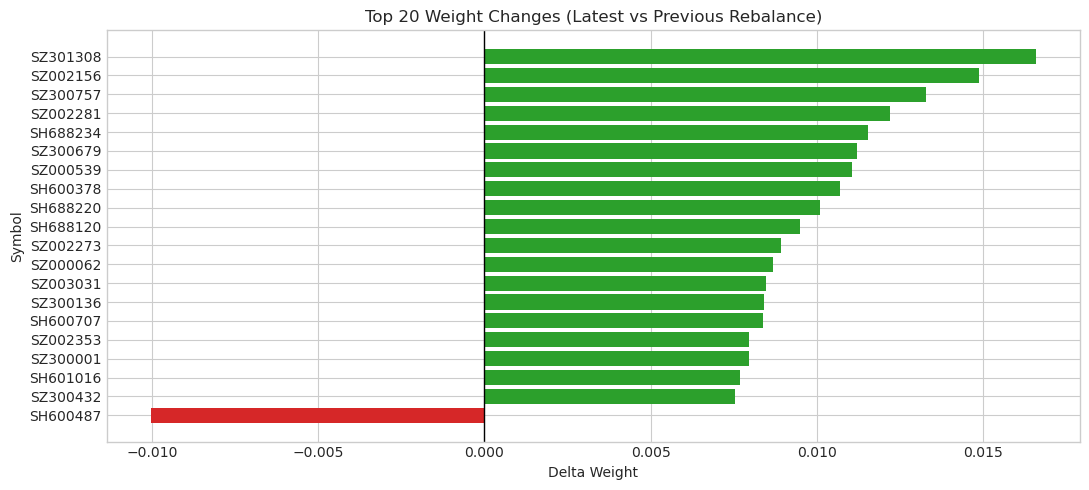

In [7]:
if weights_history is not None and len(weights_history) > 0:
    weight_cols = [c for c in weights_history.columns if c != 'trade_date']
    w_long = weights_history.melt(id_vars='trade_date', value_vars=weight_cols, var_name='symbol', value_name='weight')
    w_long['weight'] = pd.to_numeric(w_long['weight'], errors='coerce').fillna(0.0)
    w_long = w_long[w_long['weight'] > 0.0]
    latest_date = w_long['trade_date'].max()
    latest_w = w_long[w_long['trade_date'] == latest_date].sort_values('weight', ascending=False)
    prev_dates = sorted(d for d in w_long['trade_date'].unique() if d < latest_date)
    prev_date = prev_dates[-1] if prev_dates else None
    latest_total = float(latest_w['weight'].sum())
    hhi = float((latest_w['weight'] ** 2).sum())
    effective_n = (1.0 / hhi) if hhi > 0 else 0.0
    concentration = pd.DataFrame([
        {'metric': 'latest_trade_date', 'value': latest_date},
        {'metric': 'previous_trade_date', 'value': prev_date},
        {'metric': 'positions_count', 'value': int(len(latest_w))},
        {'metric': 'sum_weights', 'value': latest_total},
        {'metric': 'top_10_weight', 'value': float(latest_w['weight'].head(10).sum())},
        {'metric': 'top_20_weight', 'value': float(latest_w['weight'].head(20).sum())},
        {'metric': 'hhi', 'value': hhi},
        {'metric': 'effective_n', 'value': effective_n},
    ])
    display(concentration)
    display(latest_w.head(25).reset_index(drop=True))

    fig, ax = plt.subplots(figsize=(11, 4.2))
    topn = latest_w.head(20)
    ax.bar(topn['symbol'], topn['weight'])
    ax.set_title('Top 20 Weights (Latest Rebalance)')
    ax.set_xlabel('Symbol')
    ax.set_ylabel('Weight')
    ax.tick_params(axis='x', rotation=70)
    plt.tight_layout()
    plt.show()

    if prev_date is not None:
        prev_w = w_long[w_long['trade_date'] == prev_date][['symbol', 'weight']].rename(columns={'weight': 'prev_weight'})
        latest_comp = latest_w[['symbol', 'weight']].rename(columns={'weight': 'latest_weight'})
        weight_changes = latest_comp.merge(prev_w, on='symbol', how='outer').fillna(0.0)
        weight_changes['delta_weight'] = weight_changes['latest_weight'] - weight_changes['prev_weight']
        weight_changes['abs_delta_weight'] = weight_changes['delta_weight'].abs()
        weight_changes = weight_changes.sort_values('abs_delta_weight', ascending=False)
        display(weight_changes.head(25).reset_index(drop=True))

        fig, ax = plt.subplots(figsize=(11, 5.0))
        top_delta = weight_changes.head(20).sort_values('delta_weight')
        colors = ['#2ca02c' if v >= 0 else '#d62728' for v in top_delta['delta_weight']]
        ax.barh(top_delta['symbol'], top_delta['delta_weight'], color=colors)
        ax.axvline(0.0, color='black', linewidth=1)
        ax.set_title('Top 20 Weight Changes (Latest vs Previous Rebalance)')
        ax.set_xlabel('Delta Weight')
        ax.set_ylabel('Symbol')
        plt.tight_layout()
        plt.show()
    else:
        print('Only one rebalance snapshot is available; no weight-change comparison to display.')
else:
    print('weights_history.csv not found for selected run.')


,trade_date,orders_count,gross_notional,net_notional,estimated_cost
29,2024-11-29,296,430207.626044,-2.440234e-11,215.103813
30,2024-12-31,261,368574.376753,-4.802867e-11,184.287188
31,2025-01-27,263,365962.712339,5.976713e-11,182.981356
32,2025-02-28,246,383361.865685,-5.797703e-02,191.680933
33,2025-03-31,262,383310.682268,2.728484e-11,191.655341
34,2025-04-30,261,346858.425934,3.264633e-11,173.429213
35,2025-05-30,273,364104.388956,5.366019e-11,182.052194
36,2025-06-30,265,395967.224036,-1.147100e-10,197.983612
37,2025-07-31,269,394190.884690,1.126637e-10,197.095442
38,2025-08-29,274,478279.827479,-3.069545e-12,239.139914


,trade_date,symbol,action,delta_weight,notional,estimated_cost
11591,2026-01-30,SZ002797,SELL,-0.027855,-28361.028221,14.180514
10438,2025-09-30,SZ000423,SELL,-0.026818,-23865.022817,11.932511
11439,2026-01-30,SH601665,SELL,-0.022296,-22701.237716,11.350619
11040,2025-11-28,SZ002607,SELL,-0.024234,-20178.632959,10.089316
11654,2026-02-27,SH600171,SELL,-0.019017,-20005.508096,10.002754
2903,2023-04-28,SH603077,SELL,-0.021217,-19118.130659,9.559065
11107,2025-12-31,SH600109,SELL,-0.020700,-18560.969003,9.280485
9563,2025-06-30,SH603160,SELL,-0.025614,-18357.442573,9.178721
1354,2022-10-31,SH601179,SELL,-0.020995,-18116.244140,9.058122
7657,2024-11-29,SH600332,SELL,-0.024206,-17628.675944,8.814338


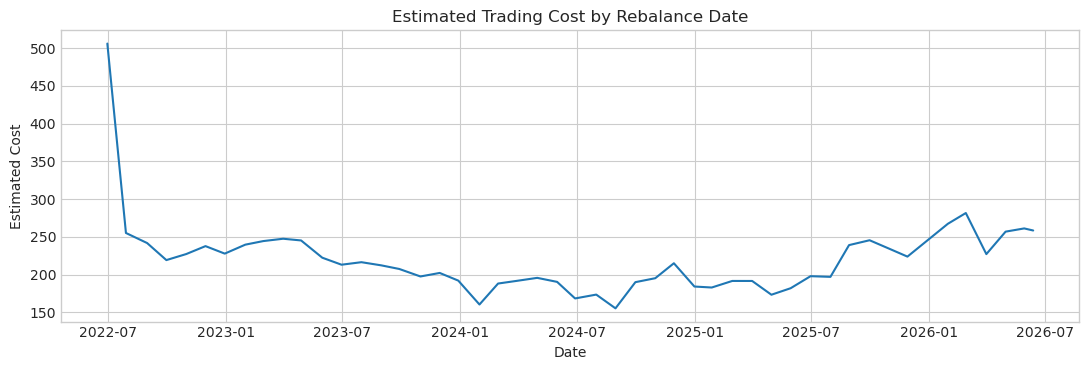

In [8]:
if orders_history is not None and len(orders_history) > 0 and 'trade_date' in orders_history.columns:
    o = orders_history.copy()
    o['notional'] = pd.to_numeric(o.get('notional', 0.0), errors='coerce').fillna(0.0)
    o['estimated_cost'] = pd.to_numeric(o.get('estimated_cost', 0.0), errors='coerce').fillna(0.0)
    daily_orders = o.groupby('trade_date', as_index=False).agg(
        orders_count=('symbol', 'size'),
        gross_notional=('notional', lambda x: float(x.abs().sum())),
        net_notional=('notional', 'sum'),
        estimated_cost=('estimated_cost', 'sum'),
    ).sort_values('trade_date')
    display(daily_orders.tail(20))

    largest_orders = o.assign(abs_notional=o['notional'].abs()).sort_values('abs_notional', ascending=False)
    display(largest_orders[['trade_date', 'symbol', 'action', 'delta_weight', 'notional', 'estimated_cost']].head(25))

    fig, ax = plt.subplots(figsize=(11, 3.8))
    ax.plot(daily_orders['trade_date'], daily_orders['estimated_cost'])
    ax.set_title('Estimated Trading Cost by Rebalance Date')
    ax.set_xlabel('Date')
    ax.set_ylabel('Estimated Cost')
    plt.tight_layout()
    plt.show()
else:
    print('orders_history.csv not found or missing trade_date column.')
